# Loading Dataset

In [138]:
import pandas as pd

# Load the dataset from csv
dataset = pd.read_csv("dataset.csv")

# Drop missing values
dataset = dataset.dropna()

print(dataset.head())

   id  Gender   Age           City Profession  Academic Pressure  \
0   2    Male  33.0  Visakhapatnam    Student                5.0   
1   8  Female  24.0      Bangalore    Student                2.0   
2  26    Male  31.0       Srinagar    Student                3.0   
3  30  Female  28.0       Varanasi    Student                3.0   
4  32  Female  25.0         Jaipur    Student                4.0   

   Work Pressure  CGPA  Study Satisfaction  Job Satisfaction  \
0            0.0  8.97                 2.0               0.0   
1            0.0  5.90                 5.0               0.0   
2            0.0  7.03                 5.0               0.0   
3            0.0  5.59                 2.0               0.0   
4            0.0  8.13                 3.0               0.0   

      Sleep Duration Dietary Habits   Degree  \
0          5-6 hours        Healthy  B.Pharm   
1          5-6 hours       Moderate      BSc   
2  Less than 5 hours        Healthy       BA   
3          7-8

In [139]:
# Display details for each column
for col, dtype in zip(dataset.columns, dataset.dtypes):
    print(f"{col} ({str(dtype)}): {dataset[col].nunique()} unique values")


id (int64): 27898 unique values
Gender (str): 2 unique values
Age (float64): 34 unique values
City (str): 52 unique values
Profession (str): 14 unique values
Academic Pressure (float64): 6 unique values
Work Pressure (float64): 3 unique values
CGPA (float64): 332 unique values
Study Satisfaction (float64): 6 unique values
Job Satisfaction (float64): 5 unique values
Sleep Duration (str): 5 unique values
Dietary Habits (str): 4 unique values
Degree (str): 28 unique values
Have you ever had suicidal thoughts ? (str): 2 unique values
Work/Study Hours (float64): 13 unique values
Financial Stress (float64): 5 unique values
Family History of Mental Illness (str): 2 unique values
Depression (int64): 2 unique values


In [140]:
# Statistical data for each column
print(dataset.describe())


                  id           Age  Academic Pressure  Work Pressure  \
count   27898.000000  27898.000000       27898.000000   27898.000000   
mean    70442.953402     25.822174           3.141336       0.000430   
std     40642.015063      4.905651           1.381462       0.043994   
min         2.000000     18.000000           0.000000       0.000000   
25%     35040.750000     21.000000           2.000000       0.000000   
50%     70689.000000     25.000000           3.000000       0.000000   
75%    105824.750000     30.000000           4.000000       0.000000   
max    140699.000000     59.000000           5.000000       5.000000   

               CGPA  Study Satisfaction  Job Satisfaction  Work/Study Hours  \
count  27898.000000        27898.000000      27898.000000      27898.000000   
mean       7.656160            2.943974          0.000681          7.156570   
std        1.470708            1.361122          0.044397          3.707598   
min        0.000000            0.00

# Data Pre-Processing

In [141]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Drop the id column because it's not a predictor
df = dataset.drop('id', axis=1)

# Separate the target variable (y)
X = df.drop('Depression', axis=1)
y = df['Depression']

# Train-test split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Group columns by data type
numeric_features = [
    'Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 
    'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours', 'Financial Stress'
]
categorical_features = [
    'Gender', 'City', 'Profession', 'Sleep Duration', 
    'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 
    'Family History of Mental Illness'
]

# Column transformer will convert data into usable numeric values for models to use
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),  # Numerical values are already the correct type, so just scale to unit variance
        ('cat', OneHotEncoder(handle_unknown="ignore"), categorical_features)  # Categorical variables are one-hot encoded (Google it lol)
    ])

# Apply the preprocessing
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Original X_train shape: {X_train.shape}")
print(f"Processed X_train shape: {X_train_processed.shape}")

Original X_train shape: (22318, 16)
Processed X_train shape: (22318, 114)


# Model Evaluation Tools

In [142]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
import matplotlib.pyplot as plt

def evaluate_model(model, X_test, y_test, name="Model"):
    """Evaluate the provided model. Finds ROC-AUC score and displays confusion matrix"""
    y_pred = model.predict(X_test)
    
    # If the model supports ROC-AUC, find it
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    else:
        auc = None

    # Display the results
    print(f"\n--- {name} Classification Report ---")
    print(classification_report(y_test, y_pred))
    if auc is not None:
        print(f"{name} ROC-AUC: {auc:.4f}")

    # Display the confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Not Depressed", "Depressed"]
    )
    disp.plot(cmap="Blues")
    plt.title(f"{name} Confusion Matrix")
    plt.show()

    return auc

def show_feature_importance(model, preprocessor, top_n=10):
    feature_names = preprocessor.get_feature_names_out()
    coefficients = model.coef_[0]

    feature_importance = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": coefficients
    })

    feature_importance = feature_importance.sort_values(
        by="Coefficient",
        ascending=False
    )

    print(f"\n--- Top {top_n} Features Increasing Risk ---")
    print(feature_importance.head(top_n).to_string(index=False))

    print(f"\n--- Top {top_n} Features Decreasing Risk ---")
    print(feature_importance.tail(top_n).to_string(index=False))

# Logistic Regression

## Standard (All predictors)


--- Standard Logistic Regression Classification Report ---
              precision    recall  f1-score   support

           0       0.79      0.84      0.81      2313
           1       0.88      0.84      0.86      3267

    accuracy                           0.84      5580
   macro avg       0.84      0.84      0.84      5580
weighted avg       0.84      0.84      0.84      5580

Standard Logistic Regression ROC-AUC: 0.9185


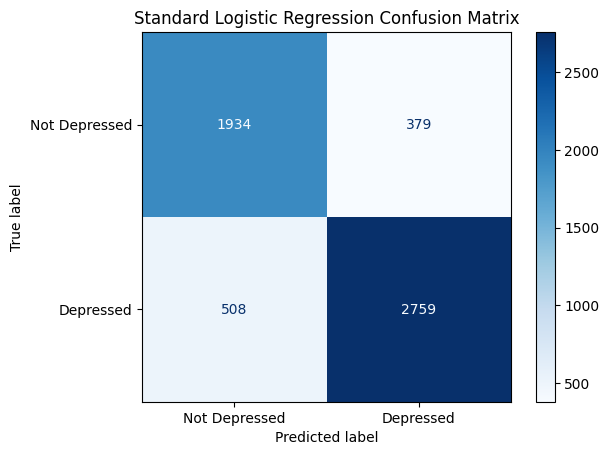


--- Top 10 Features Increasing Risk ---
                                       Feature  Coefficient
cat__Have you ever had suicidal thoughts ?_Yes     1.477832
                        num__Academic Pressure     1.151870
                         num__Financial Stress     0.814224
                    cat__Dietary Habits_Others     0.626581
                 cat__Dietary Habits_Unhealthy     0.495789
                            cat__Degree_Others     0.467013
                     cat__Profession_Architect     0.461000
                         num__Work/Study Hours     0.456502
         cat__Sleep Duration_Less than 5 hours     0.415531
                        cat__Profession_Doctor     0.374291

--- Top 10 Features Decreasing Risk ---
                                      Feature  Coefficient
                               cat__City_Agra    -0.297462
                             cat__City_Jaipur    -0.301217
                      num__Study Satisfaction    -0.333742
                      

In [143]:
from sklearn.linear_model import LogisticRegression

# Build the logistic regression model ("balanced" means classes are given equal weight)
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

# Train the model
log_reg.fit(X_train_processed, y_train)

# Make predictions on the test data
y_pred = log_reg.predict(X_test_processed)

# Evaluate the model
evaluate_model(log_reg, X_test_processed, y_test, "Standard Logistic Regression")

# Rank features by importance
show_feature_importance(log_reg, preprocessor)

## Sparse (Using Lasso Regression)

e:\Programming\Repositories\STAT-4210-Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
e:\Programming\Repositories\STAT-4210-Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(



--- Sparse Logistic Regression Classification Report ---
              precision    recall  f1-score   support

           0       0.79      0.84      0.81      2313
           1       0.88      0.85      0.86      3267

    accuracy                           0.84      5580
   macro avg       0.84      0.84      0.84      5580
weighted avg       0.84      0.84      0.84      5580

Sparse Logistic Regression ROC-AUC: 0.9188


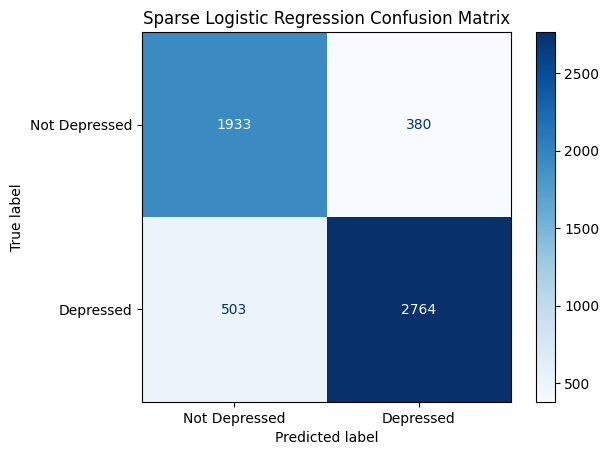


--- Top 10 Features Increasing Risk ---
                                       Feature  Coefficient
cat__Have you ever had suicidal thoughts ?_Yes     1.170455
                        num__Academic Pressure     1.136150
                         num__Financial Stress     0.804950
                 cat__Dietary Habits_Unhealthy     0.564532
                         num__Work/Study Hours     0.446812
         cat__Sleep Duration_Less than 5 hours     0.337318
                           cat__City_Hyderabad     0.136542
                           cat__City_Ahmedabad     0.094129
                            cat__Degree_B.Tech     0.091142
                              cat__City_Bhopal     0.080638

--- Top 10 Features Decreasing Risk ---
                                      Feature  Coefficient
                             cat__City_Mumbai    -0.138595
                             cat__City_Nagpur    -0.195422
     cat__Family History of Mental Illness_No    -0.201144
                      

In [144]:
# Build the logistic regression model (use lasso regularization)
log_reg_sparse = LogisticRegression(
    penalty="l1",
    solver="saga",
    C=0.1,
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

# Train the model
log_reg_sparse.fit(X_train_processed, y_train)

# Make predictions on the test data
y_pred = log_reg_sparse.predict(X_test_processed)

# Evaluate the model
evaluate_model(log_reg_sparse, X_test_processed, y_test, "Sparse Logistic Regression")

# Rank features by importance
show_feature_importance(log_reg_sparse, preprocessor)

In [ ]:
import numpy as np

# Calculate the number of models that were removed by Lasso
coef = log_reg_sparse.coef_[0]
non_zero = np.sum(coef != 0)
total = len(coef)

print(f"Non-zero features: {non_zero}")
print(f"Total features: {total}")
print(f"Sparsity: {100 * (1 - non_zero/total):.2f}% features removed")

Non-zero features: 35
Total features: 114
Sparsity: 69.30% features removed
